<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


C:\Users\aungt\AppData\Local\Temp\ipykernel_15796\654858277.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


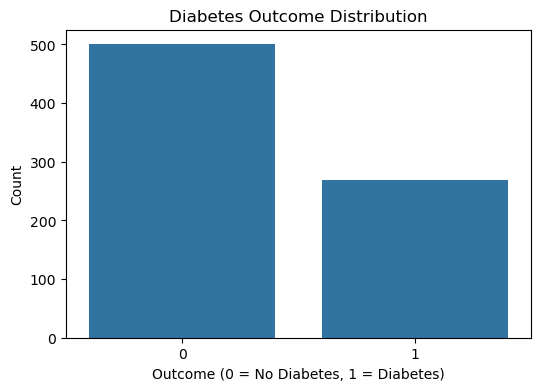

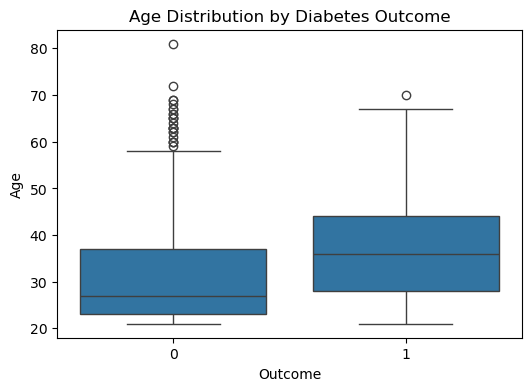

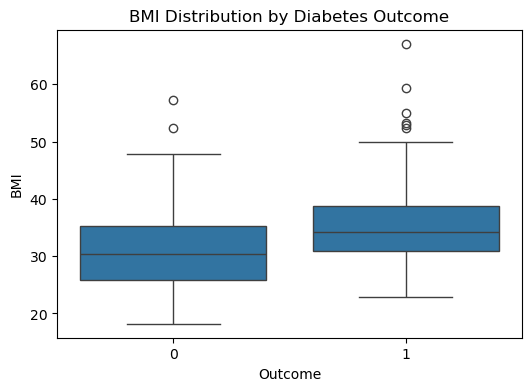

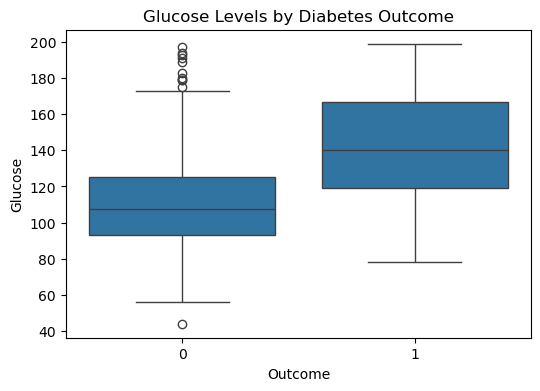

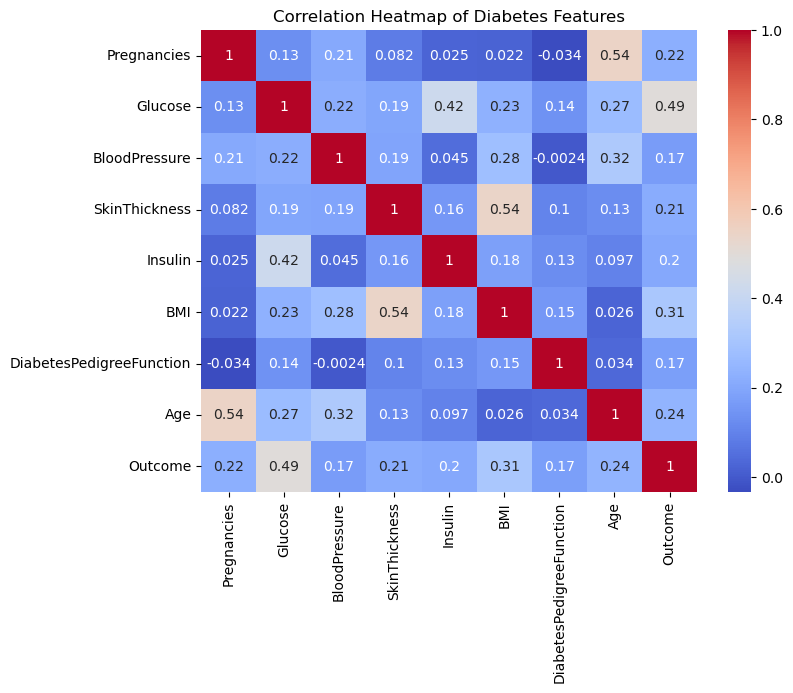

Model Accuracy: 0.7532467532467533

Confusion Matrix:
[[82 17]
 [21 34]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Random Forest Accuracy: 0.7402597402597403

Random Forest Confusion Matrix:
[[78 21]
 [19 36]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        99
           1       0.63      0.65      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154

Logistic Regression Accuracy: 0.7532467532467533
Random Forest Accuracy: 0.7402597402597403
Glucose                 

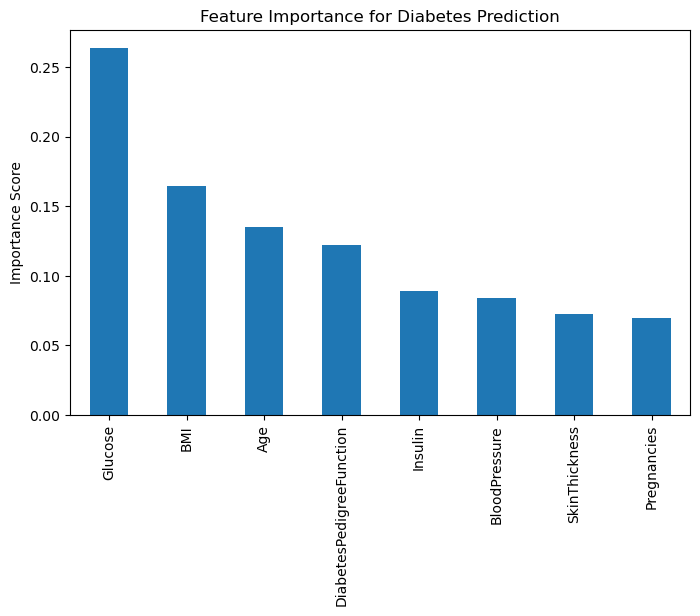

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2      130             70             25      120  28.5   

   DiabetesPedigreeFunction  Age  
0                      0.45   35  
✅ Diabetes Risk: LOW (Negative)
✅ No Diabetes
<class 'sklearn.preprocessing._data.StandardScaler'>


d:\for ana\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/diabetes.csv")
df.head()

df.shape
df.info()
df.describe()

df['Outcome'].value_counts()

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

(df[zero_cols] == 0).sum()

df[zero_cols] = df[zero_cols].replace(0, np.nan)

df.isnull().sum()

for col in zero_cols:
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()
(df[zero_cols] == 0).sum()

df.describe()

plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Age', data=df)
plt.title("Age Distribution by Diabetes Outcome")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='BMI', data=df)
plt.title("BMI Distribution by Diabetes Outcome")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose Levels by Diabetes Outcome")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Diabetes Features")
plt.show()

X = df.drop('Outcome', axis=1)
y = df['Outcome']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# =========================
# DAY 5: MODEL & EVALUATION
# =========================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf_accuracy = accuracy_score(y_test, rf_y_pred)
print("Random Forest Accuracy:", rf_accuracy)

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_y_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

plt.figure(figsize=(8,5))
feature_importance.plot(kind='bar')
plt.title("Feature Importance for Diabetes Prediction")
plt.ylabel("Importance Score")
plt.show()

# New patient data (example)
new_patient = {
    "Pregnancies": 2,
    "Glucose": 130,
    "BloodPressure": 70,
    "SkinThickness": 25,
    "Insulin": 120,
    "BMI": 28.5,
    "DiabetesPedigreeFunction": 0.45,
    "Age": 35
}

new_df = pd.DataFrame([new_patient])
print(new_df)

new_df_scaled = scaler.transform(new_df)
prediction = rf_model.predict(new_df_scaled)

if prediction[0] == 1:
    print("⚠️ Diabetes Risk: HIGH (Positive)")
else:
    print("✅ Diabetes Risk: LOW (Negative)")

import pickle
# Save trained model
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

# Save scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

import pickle
import numpy as np

with open("diabetes_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# [Pregnancies, Glucose, BloodPressure, SkinThickness,
#  Insulin, BMI, DiabetesPedigreeFunction, Age]

new_data = np.array([[2, 120, 70, 25, 90, 28.5, 0.45, 35]])
new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)

if prediction[0] == 1:
    print("⚠️ Diabetes Detected")
else:
    print("✅ No Diabetes")



